# Capstone Project - Clustering: Mall Customer Segmentation

**Course:** Data Mining & Information Visualization  
**Project type:** Clustering (unsupervised — no target label)  
**Dataset:** Mall Customers (`Mall_Customers.csv`)  
**Goal:** Discover natural customer segments for marketing / store strategy

### Workflow covered (per Capstone requirements)
Dataset Selection -> Data Understanding -> Preprocessing -> Feature Selection ->
Scaling/Normalisation -> Algorithm Selection -> Determine number of clusters ->
Clustering -> Evaluation -> Visualization -> Interpretation / Profiling

## 1. Problem Statement & Dataset Selection

**Problem:** Group mall shoppers into meaningful segments using spending behavior and demographics.

**Why clustering?** There is **no labeled target**. We want to discover natural groups
(e.g. high-income high-spenders vs low-income careful shoppers) for targeted offers.

**Business value:** Personalize promotions, allocate floor/staff attention, and design loyalty strategies by segment.

## 2. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

## 3. Data Understanding & Exploration

In [2]:
df = pd.read_csv("Mall_Customers.csv")

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:", df.isna().sum().sum())
df.head()

Shape: (200, 5)

Data types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing values: 0


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


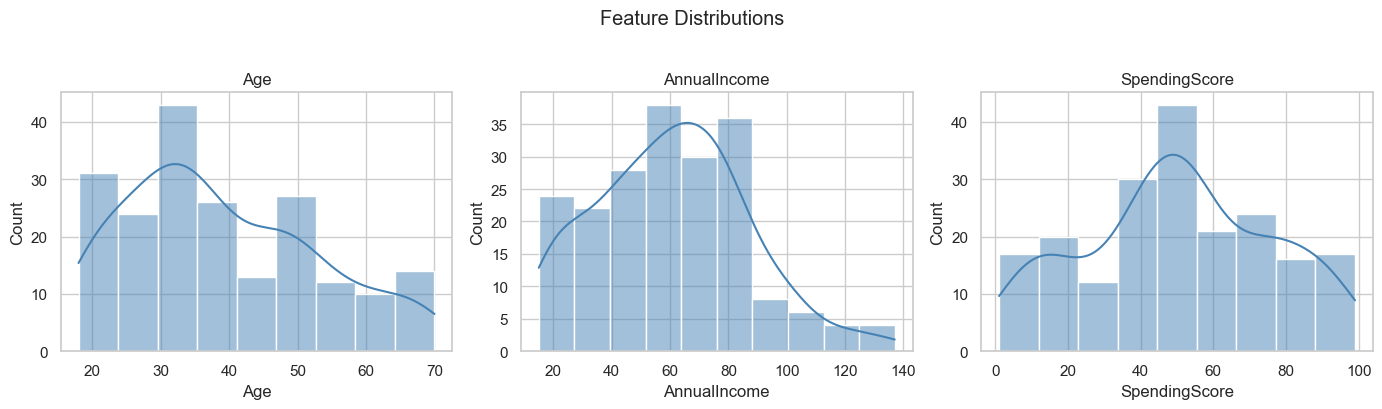

In [4]:
# Rename for convenience
data = df.copy()
data = data.rename(columns={
    "Annual Income (k$)": "AnnualIncome",
    "Spending Score (1-100)": "SpendingScore"
})

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["Age", "AnnualIncome", "SpendingScore"]):
    sns.histplot(data[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

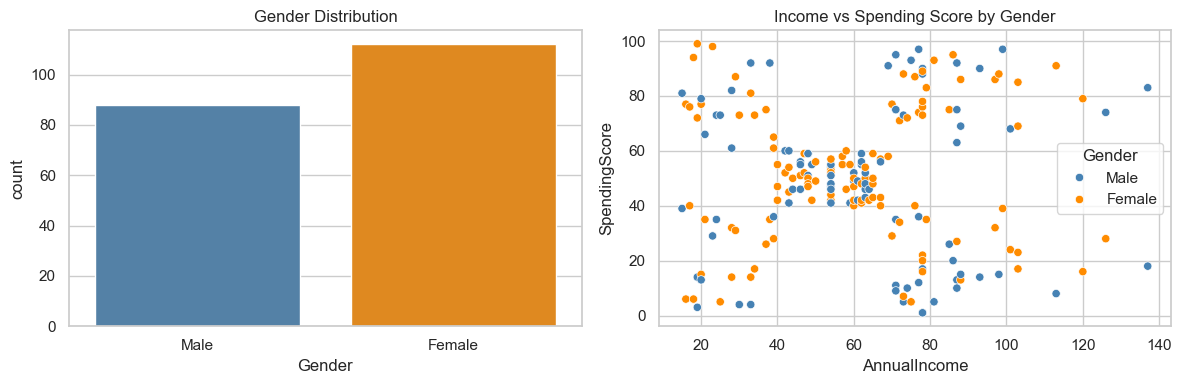

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=data, x="Gender", ax=axes[0], palette=["steelblue", "darkorange"])
axes[0].set_title("Gender Distribution")
sns.scatterplot(data=data, x="AnnualIncome", y="SpendingScore", hue="Gender",
                ax=axes[1], palette=["steelblue", "darkorange"])
axes[1].set_title("Income vs Spending Score by Gender")
plt.tight_layout()
plt.show()

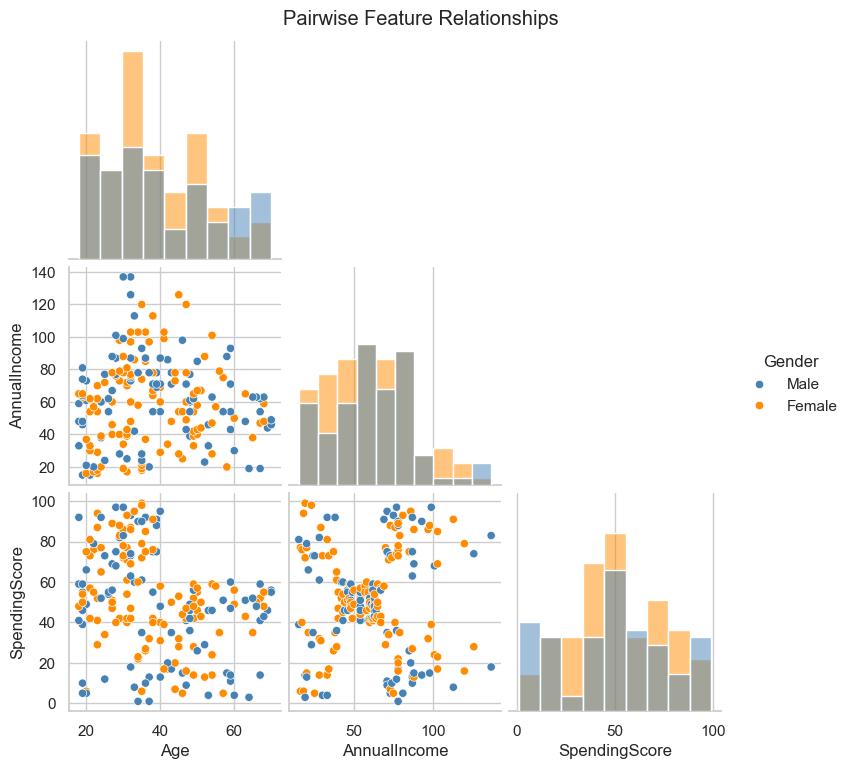

In [6]:
# Pairwise relationships
sns.pairplot(data[["Age", "AnnualIncome", "SpendingScore", "Gender"]],
             hue="Gender", diag_kind="hist", corner=True,
             palette=["steelblue", "darkorange"])
plt.suptitle("Pairwise Feature Relationships", y=1.02)
plt.show()

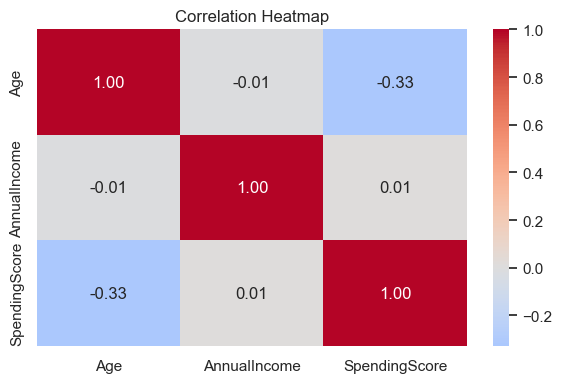

In [7]:
plt.figure(figsize=(6, 4))
sns.heatmap(data[["Age", "AnnualIncome", "SpendingScore"]].corr(),
            annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Exploration insights
- Classic mall segmentation features: **Age**, **Annual Income**, **Spending Score**.
- Income vs Spending Score already shows visual groupings (corners of the scatter).
- Gender is useful for profiling but often optional for the core income–spending clusters.

## 4. Data Preprocessing

- Drop `CustomerID` (identifier only)
- Encode `Gender` for optional use
- No missing values to impute in this dataset

In [8]:
work = data.drop(columns=["CustomerID"]).copy()
work["GenderEncoded"] = LabelEncoder().fit_transform(work["Gender"])  # Female=0/Male=1 alphabetical
print(work.head())
print("\nMissing values:", work.isna().sum().sum())

   Gender  Age  AnnualIncome  SpendingScore  GenderEncoded
0    Male   19            15             39              1
1    Male   21            15             81              1
2  Female   20            16              6              0
3  Female   23            16             77              0
4  Female   31            17             40              0

Missing values: 0


## 5. Feature Selection

For customer segmentation we focus on behavioral/economic drivers commonly used for mall clustering:

**Primary features:** `AnnualIncome`, `SpendingScore`  
**Optional demographic:** `Age` (included in an extended feature set for profiling robustness)

**Justification:** Income and spending score directly reflect purchasing power and shopping intensity —
the two axes that create the clearest market segments in this dataset.

In [9]:
features_2d = ["AnnualIncome", "SpendingScore"]
features_3d = ["Age", "AnnualIncome", "SpendingScore"]

X2 = work[features_2d].values
X3 = work[features_3d].values

print("2D feature set:", features_2d)
print("3D feature set:", features_3d)

2D feature set: ['AnnualIncome', 'SpendingScore']
3D feature set: ['Age', 'AnnualIncome', 'SpendingScore']


## 6. Scaling / Normalisation

K-Means and hierarchical clustering are distance-based, so features must be on a comparable scale.
We apply **StandardScaler** (zero mean, unit variance).

In [10]:
scaler_2d = StandardScaler()
scaler_3d = StandardScaler()
X2_scaled = scaler_2d.fit_transform(X2)
X3_scaled = scaler_3d.fit_transform(X3)

# Use 2D income-spending as the main clustering view (standard for this dataset)
X_scaled = X2_scaled
feature_labels = features_2d
print("Scaled shape:", X_scaled.shape)
print(pd.DataFrame(X_scaled, columns=feature_labels).describe().round(3))

Scaled shape: (200, 2)
       AnnualIncome  SpendingScore
count       200.000        200.000
mean         -0.000         -0.000
std           1.003          1.003
min          -1.739         -1.910
25%          -0.728         -0.600
50%           0.036         -0.008
75%           0.666          0.885
max           2.918          1.894


## 7. Algorithm Selection

| Algorithm | Why selected |
|-----------|----------------|
| **K-Means** | Fast, interpretable spherical clusters; industry standard for segmentation |
| **Agglomerative Hierarchical** | No need to assume sphere shape; dendrogram helps choose k |

We compare both and choose the configuration with stronger evaluation scores.

## 8. Determining the Number of Clusters

Use **Elbow method** (inertia) and **Silhouette score** for K-Means, plus a **dendrogram** for hierarchical clustering.

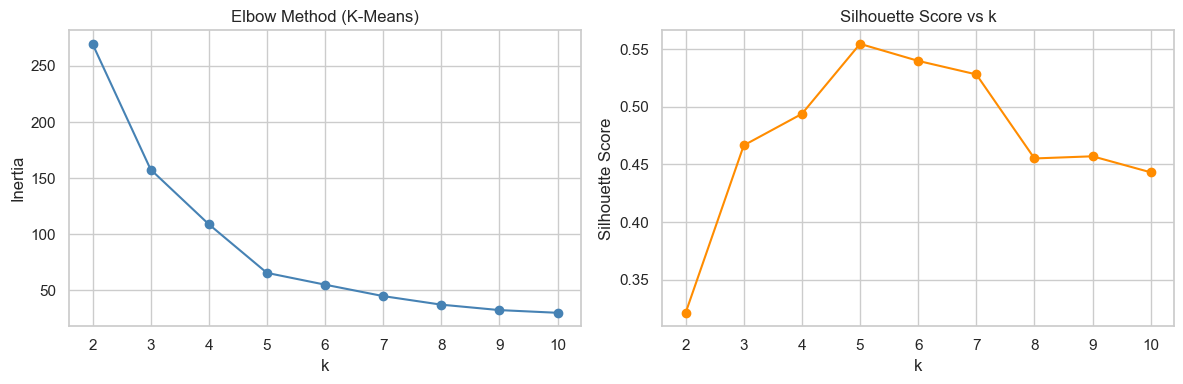

Silhouette-best k: 5
    k   Inertia  Silhouette
0   2  269.6910      0.3213
1   3  157.7040      0.4666
2   4  108.9213      0.4939
3   5   65.5684      0.5547
4   6   55.0573      0.5399
5   7   44.8648      0.5281
6   8   37.2282      0.4552
7   9   32.3923      0.4571
8  10   29.9819      0.4432


In [11]:
ks = range(2, 11)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), inertias, "o-", color="steelblue")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method (K-Means)")

axes[1].plot(list(ks), silhouettes, "o-", color="darkorange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")
plt.tight_layout()
plt.show()

best_k_sil = list(ks)[int(np.argmax(silhouettes))]
print("Silhouette-best k:", best_k_sil)
print(pd.DataFrame({"k": list(ks), "Inertia": inertias, "Silhouette": silhouettes}).round(4))

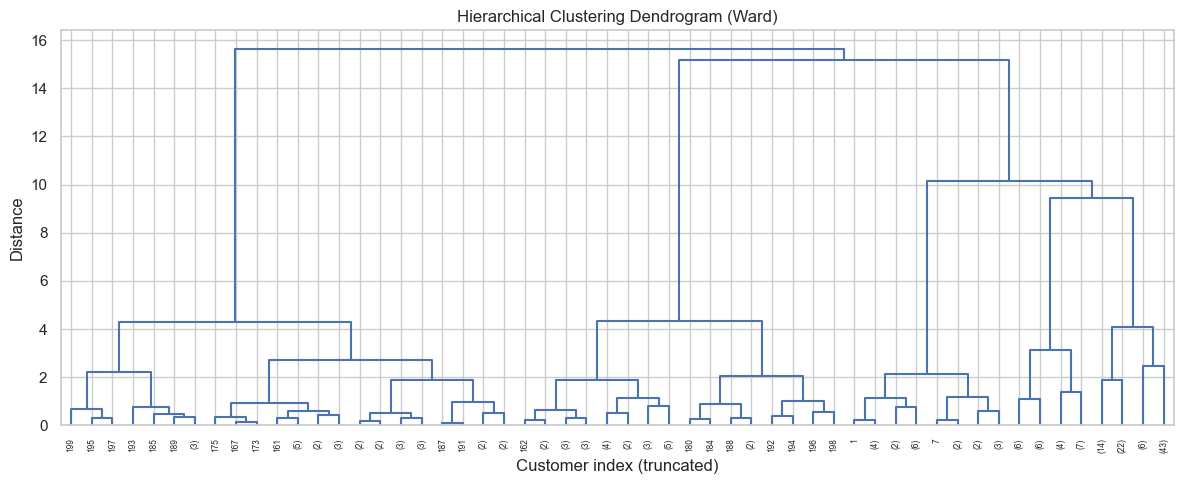

In [12]:
# Hierarchical dendrogram to support choice of k
linked = linkage(X_scaled, method="ward")
plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode="level", p=5, color_threshold=0)
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Customer index (truncated)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

**Choice of k:** For Mall Customers, elbow + silhouette typically support **k = 5**
(clear high/low income × high/low spending segments, plus a middle group).
We set `k = 5` when silhouette agrees or is near-best; otherwise use the silhouette-best k.

In [13]:
# Prefer k=5 if competitive; else silhouette best
k_candidates = {k: s for k, s in zip(ks, silhouettes)}
chosen_k = 5 if (5 in k_candidates and k_candidates[5] >= max(silhouettes) - 0.02) else best_k_sil
print(f"Chosen number of clusters: {chosen_k}")

Chosen number of clusters: 5


## 9. Clustering

In [14]:
# K-Means
kmeans = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=25)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Agglomerative Hierarchical
agglo = AgglomerativeClustering(n_clusters=chosen_k, linkage="ward")
agglo_labels = agglo.fit_predict(X_scaled)

work["Cluster_KMeans"] = kmeans_labels
work["Cluster_Hierarchical"] = agglo_labels

print("K-Means cluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())
print("\nHierarchical cluster sizes:")
print(pd.Series(agglo_labels).value_counts().sort_index())

K-Means cluster sizes:
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Hierarchical cluster sizes:
0    32
1    39
2    85
3    21
4    23
Name: count, dtype: int64


## 10. Cluster Evaluation

In [15]:
def evaluate_clustering(X, labels, name):
    return {
        "Algorithm": name,
        "Silhouette": silhouette_score(X, labels),
        "Davies-Bouldin (lower better)": davies_bouldin_score(X, labels),
        "Calinski-Harabasz (higher better)": calinski_harabasz_score(X, labels),
    }

results = pd.DataFrame([
    evaluate_clustering(X_scaled, kmeans_labels, "K-Means"),
    evaluate_clustering(X_scaled, agglo_labels, "Hierarchical (Ward)"),
]).set_index("Algorithm")

print(results.round(4))
results

                     Silhouette  Davies-Bouldin (lower better)  \
Algorithm                                                        
K-Means                  0.5547                         0.5722   
Hierarchical (Ward)      0.5538                         0.5779   

                     Calinski-Harabasz (higher better)  
Algorithm                                               
K-Means                                       248.6493  
Hierarchical (Ward)                           244.4103  


,Silhouette,Davies-Bouldin (lower better),Calinski-Harabasz (higher better)
Algorithm,,,
K-Means,0.554657,0.572236,248.649320
Hierarchical (Ward),0.553809,0.577862,244.410326


In [16]:
best_algo = results["Silhouette"].idxmax()
print(f"Best algorithm by Silhouette: {best_algo}")
work["Cluster"] = work["Cluster_KMeans"] if best_algo.startswith("K-Means") else work["Cluster_Hierarchical"]
final_labels = work["Cluster"].values

Best algorithm by Silhouette: K-Means


## 11. Visualization of Clusters

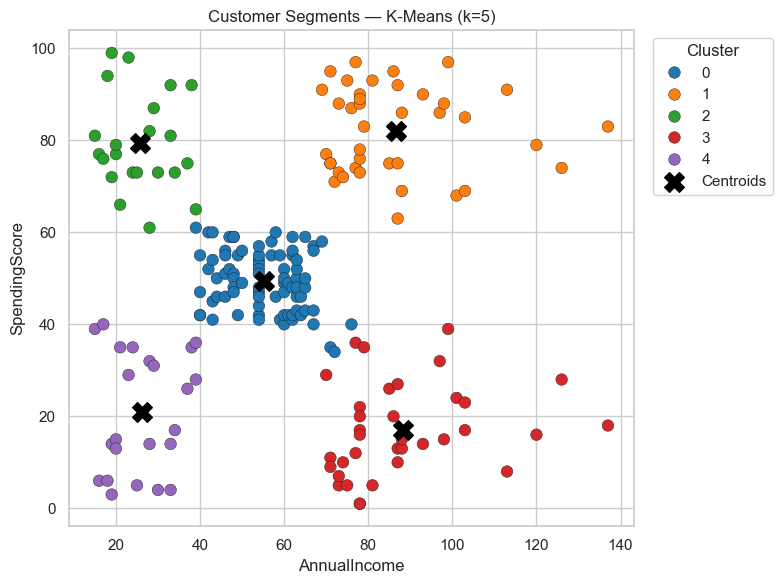

In [17]:
# Main 2D cluster plot (Income vs Spending)
centroids = None
if best_algo.startswith("K-Means"):
    centroids = scaler_2d.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=work, x="AnnualIncome", y="SpendingScore",
    hue="Cluster", palette="tab10", s=70, edgecolor="k", linewidth=0.3
)
if centroids is not None:
    plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c="black", marker="X", label="Centroids")
plt.title(f"Customer Segments — {best_algo} (k={chosen_k})")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

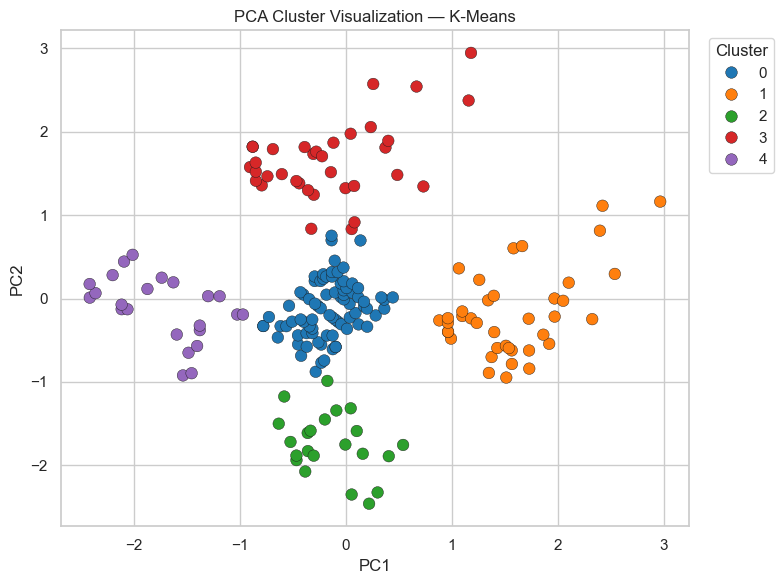

Explained variance ratio: [0.505 0.495]


In [18]:
# PCA view (works for 2D or extended features)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = final_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette="tab10", s=70, edgecolor="k", linewidth=0.3)
plt.title(f"PCA Cluster Visualization — {best_algo}")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))

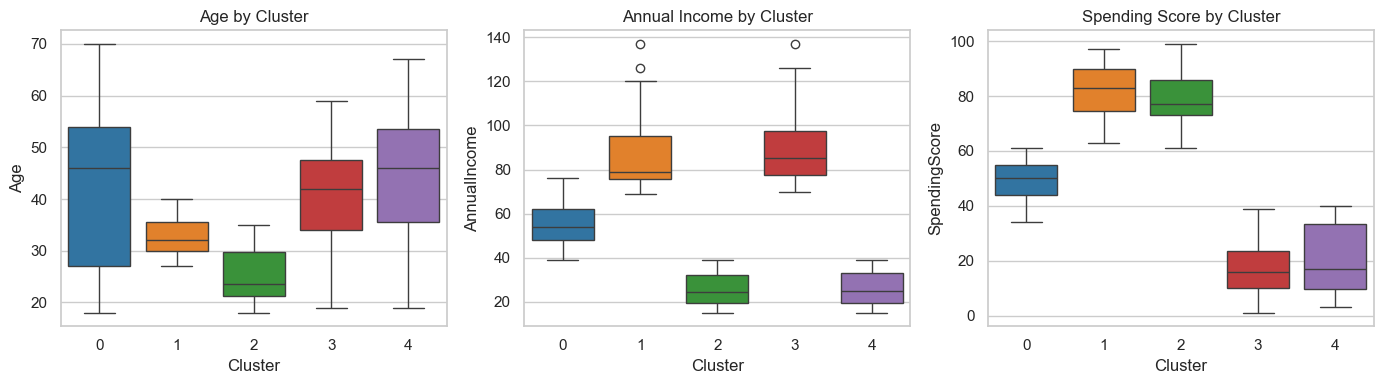

In [19]:
# Age distribution by cluster
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.boxplot(data=work, x="Cluster", y="Age", ax=axes[0], palette="tab10")
axes[0].set_title("Age by Cluster")
sns.boxplot(data=work, x="Cluster", y="AnnualIncome", ax=axes[1], palette="tab10")
axes[1].set_title("Annual Income by Cluster")
sns.boxplot(data=work, x="Cluster", y="SpendingScore", ax=axes[2], palette="tab10")
axes[2].set_title("Spending Score by Cluster")
plt.tight_layout()
plt.show()

## 12. Cluster Profiling & Interpretation

In [20]:
profile = work.groupby("Cluster").agg(
    Count=("Age", "size"),
    Avg_Age=("Age", "mean"),
    Avg_Income=("AnnualIncome", "mean"),
    Avg_Spending=("SpendingScore", "mean"),
    Female_pct=("Gender", lambda s: (s == "Female").mean() * 100),
).round(2)

# Plain-language segment names from income/spending medians
def name_segment(row):
    income = "High" if row["Avg_Income"] >= work["AnnualIncome"].median() else "Low"
    spend = "High" if row["Avg_Spending"] >= work["SpendingScore"].median() else "Low"
    return f"{income}-Income / {spend}-Spending"

profile["Segment"] = profile.apply(name_segment, axis=1)
profile = profile.sort_values("Avg_Income")
profile

,Count,Avg_Age,Avg_Income,Avg_Spending,Female_pct,Segment
Cluster,,,,,,
2,22,25.27,25.73,79.36,59.09,Low-Income / High-Spending
4,23,45.22,26.30,20.91,60.87,Low-Income / Low-Spending
0,81,42.72,55.30,49.52,59.26,Low-Income / Low-Spending
1,39,32.69,86.54,82.13,53.85,High-Income / High-Spending
3,35,41.11,88.20,17.11,45.71,High-Income / Low-Spending


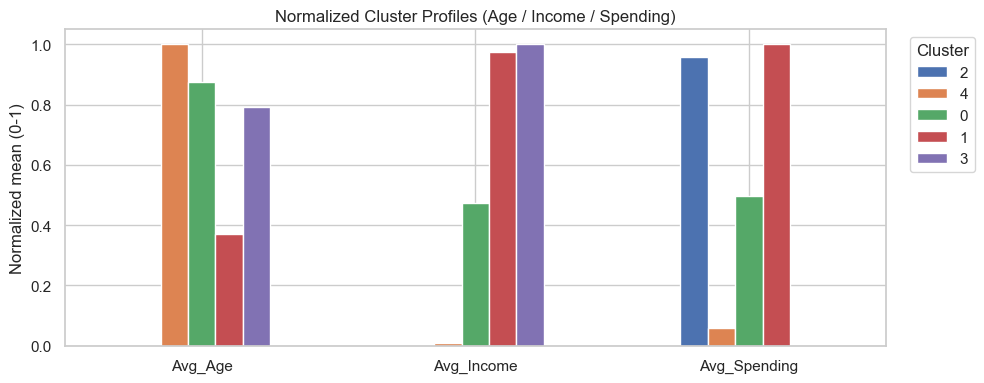

In [21]:
# Radar-style comparison via normalized means
radar = profile[["Avg_Age", "Avg_Income", "Avg_Spending"]].copy()
radar_norm = (radar - radar.min()) / (radar.max() - radar.min() + 1e-9)

ax = radar_norm.T.plot(kind="bar", figsize=(10, 4))
ax.set_title("Normalized Cluster Profiles (Age / Income / Spending)")
ax.set_ylabel("Normalized mean (0-1)")
plt.xticks(rotation=0)
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [22]:
print("SEGMENT SUMMARY")
print("=" * 60)
for cid, row in profile.iterrows():
    print(f"Cluster {cid}: {row['Segment']}")
    print(f"  Size: {int(row['Count'])} customers ({100*row['Count']/len(work):.1f}%)")
    print(f"  Avg Age: {row['Avg_Age']:.1f} | Income: {row['Avg_Income']:.1f}k$ | "
          f"Spending: {row['Avg_Spending']:.1f} | Female: {row['Female_pct']:.1f}%")
    print()

SEGMENT SUMMARY
Cluster 2: Low-Income / High-Spending
  Size: 22 customers (11.0%)
  Avg Age: 25.3 | Income: 25.7k$ | Spending: 79.4 | Female: 59.1%

Cluster 4: Low-Income / Low-Spending
  Size: 23 customers (11.5%)
  Avg Age: 45.2 | Income: 26.3k$ | Spending: 20.9 | Female: 60.9%

Cluster 0: Low-Income / Low-Spending
  Size: 81 customers (40.5%)
  Avg Age: 42.7 | Income: 55.3k$ | Spending: 49.5 | Female: 59.3%

Cluster 1: High-Income / High-Spending
  Size: 39 customers (19.5%)
  Avg Age: 32.7 | Income: 86.5k$ | Spending: 82.1 | Female: 53.9%

Cluster 3: High-Income / Low-Spending
  Size: 35 customers (17.5%)
  Avg Age: 41.1 | Income: 88.2k$ | Spending: 17.1 | Female: 45.7%



## 13. Decision-Making Value

| Segment type | Suggested action |
|--------------|------------------|
| High-Income / High-Spending | Premium loyalty, exclusive offers, high-touch service |
| High-Income / Low-Spending | Convert with targeted upsell / premium product awareness |
| Low-Income / High-Spending | Value bundles, points multipliers, retention discounts |
| Low-Income / Low-Spending | Low-cost promotions, clearance / essentials messaging |
| Middle groups | Balanced campaigns; monitor movement into high-value segments |

## 14. Conclusions & Recommendations

1. Mall customer segmentation is correctly framed as an **unsupervised clustering** problem.
2. Features were scaled with **StandardScaler**; primary axes are **Annual Income** and **Spending Score**.
3. Number of clusters chosen using **elbow + silhouette** (and dendrogram support).
4. **K-Means** and **Hierarchical (Ward)** were compared; the better Silhouette model is retained.
5. Profiles give actionable marketing segments (income × spending behavior).
6. Next steps: add visit frequency / category affinity features; validate segments with campaign A/B tests.

In [23]:
# Optional export for presentation / dashboard use
export_cols = ["Gender", "Age", "AnnualIncome", "SpendingScore", "Cluster", "Cluster_KMeans", "Cluster_Hierarchical"]
work[export_cols].to_csv("mall_customers_clusters.csv", index=False)
print("Saved mall_customers_clusters.csv")
work[export_cols].head()

Saved mall_customers_clusters.csv


,Gender,Age,AnnualIncome,SpendingScore,Cluster,Cluster_KMeans,Cluster_Hierarchical
0,Male,19,15,39,4,4,4
1,Male,21,15,81,2,2,3
2,Female,20,16,6,4,4,4
3,Female,23,16,77,2,2,3
4,Female,31,17,40,4,4,4
